# Doping diagram

We have already seen in the [Defect concentrations](./defect_concentrations.ipynb) and the [Brouwer diagram](./brouwer_diagram.ipynb) tutorials how to compute defect equilirbium when some defect concentrations are fixed to a target value. When in presence of extrinsic defects, it can be even more instructive to look at the defect equilibrium as a function of the dopants content, to produce **doping diagrams**. 

We start from our previous example of $\mathrm{Fe}$-doped $\mathrm{SrTiO_3}$ (always with made-up energies). $\mathrm{Fe}$ can substitute $\mathrm{Sr}$ on the A-site (acceptor) or $\mathrm{Ti}$ on the B-site (donor):

In [14]:
import pandas as pd
from defermi import DefectsAnalysis

bulk_volume = 800 # cubic Amstrong
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume},
{'name': 'Vac_Ti','charge': -4,'multiplicity': 1,'energy_diff': 20,'bulk_volume': bulk_volume},
{'name': 'Vac_Ti','charge': 0,'multiplicity': 1,'energy_diff': 19.7,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Sr','charge': -1,'multiplicity': 1,'energy_diff': 1.9,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Sr','charge':0,'multiplicity':1,'energy_diff': 1.5, 'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Ti','charge': 1,'multiplicity': 1,'energy_diff': 7.0,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Ti','charge': 2,'multiplicity': 1,'energy_diff': 6.5,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0.0)
da.table(display=['energy_diff'])

,name,delta atoms,charge,multiplicity,corrections,energy_diff
0,Sub_Fe_on_Sr,"{'Fe': 1, 'Sr': -1}",-1,1,{},1.9
1,Sub_Fe_on_Sr,"{'Fe': 1, 'Sr': -1}",0,1,{},1.5
2,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",1,1,{},7.0
3,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",2,1,{},6.5
4,Vac_O,{'O': -1},0,1,{},10.8
5,Vac_O,{'O': -1},2,1,{},7.0
6,Vac_Sr,{'Sr': -1},-2,1,{},8.0
7,Vac_Sr,{'Sr': -1},0,1,{},7.8
8,Vac_Ti,{'Ti': -1},-4,1,{},20.0
9,Vac_Ti,{'Ti': -1},0,1,{},19.7


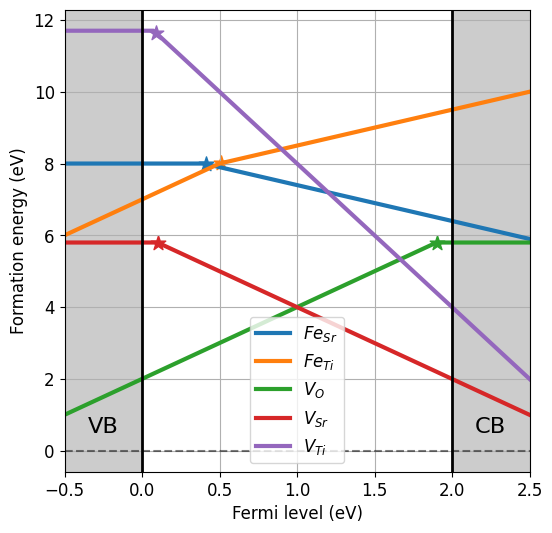

In [15]:
chempots = {'O':-5,'Sr':-2,'Fe':-8.5,'Ti':-8}
da.plot_formation_energies(chempots);

In this case, it's useful to look at the compensation mechanisms as a function of $\mathrm{Fe}$ content. We use the `plot_doping_diagram` function to produce the doping diagram. The `bulk_dos` argument for the calculation of intrinsic carriers follows the same convention as in the [Defect concentrations](./defect_concentrations.ipynb) and the [Brouwer diagram](./brouwer_diagram.ipynb) tutorials. In this case we pass effective masses. The doping species is set with the `variable_defect_specie` argument. The chemical potentials are fixed, like for formation energies.

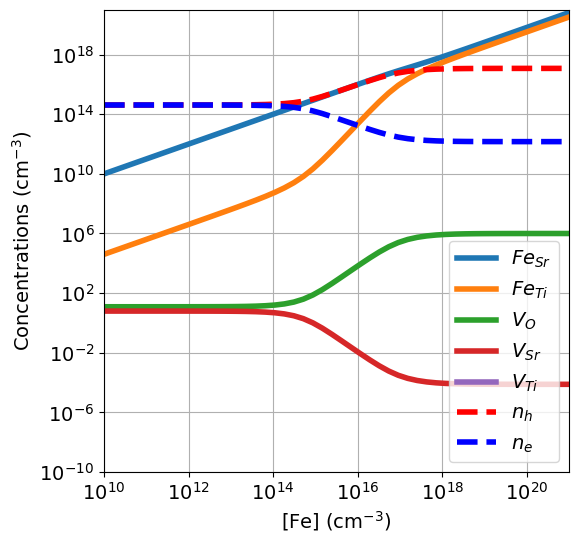

In [16]:
da.plot_doping_diagram(
                    variable_defect_specie='Fe',
                    concentration_range=(1e10,1e21),
                    chemical_potentials=chempots,
                    bulk_dos={'m_eff_e':0.5,'m_eff_h':0.4},
                    temperature=1000,
                    ylim=(1e-10,1e21),
                    figsize=(6,6),
                    fontsize=14);

We can also quench defects, like for Brouwer diagrams:

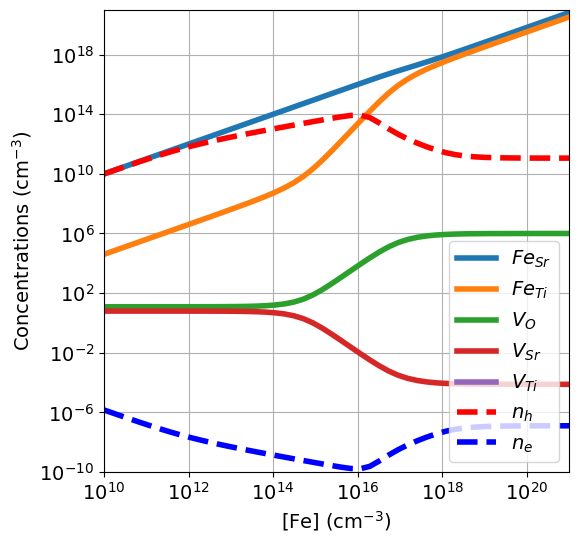

In [17]:
da.plot_doping_diagram(
                    variable_defect_specie='Fe',
                    concentration_range=(1e10,1e21),
                    chemical_potentials=chempots,
                    bulk_dos={'m_eff_e':0.5,'m_eff_h':0.4},
                    temperature=1000,
                    quench_temperature=300,
                    ylim=(1e-10,1e21),
                    figsize=(6,6),
                    fontsize=14);

In quenched conditions the compensation mechanisms change. At lower temperature the instrins carrier concentrations are lower, and the main compensation mechanisms are ionic due to the high concentrations of quenched defects.

### Generic dopants

If we don't have extrinsic defects in our dataset, we can also similate how a generic dopant would have an effect on the equilibrium. We set `variable_defect_specie` to a dictionary in the following format: `{"name":string, "charge": int or float}`. We filter the entries containing $\mathrm{Fe}$:

In [18]:
da_int = da.filter_entries(exclude=True,elements=['Fe'])
da_int

,name,delta atoms,charge,multiplicity,corrections
0,Vac_O,{'O': -1},0,1,{}
1,Vac_O,{'O': -1},2,1,{}
2,Vac_Sr,{'Sr': -1},-2,1,{}
3,Vac_Sr,{'Sr': -1},0,1,{}
4,Vac_Ti,{'Ti': -1},-4,1,{}
5,Vac_Ti,{'Ti': -1},0,1,{}


We set a generic donor called `"Donor"` with a charge of $+2$. 

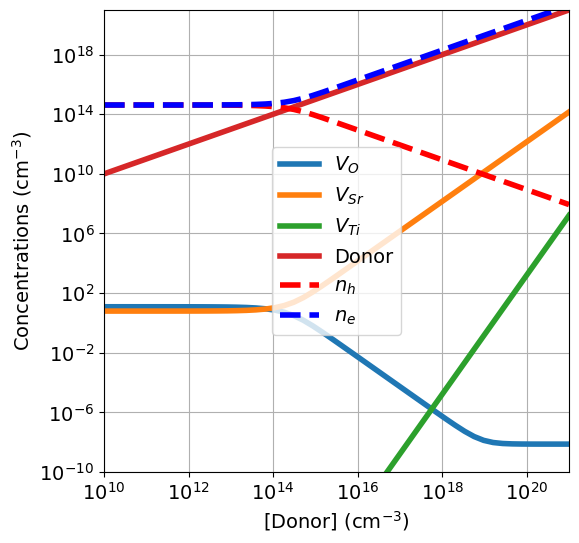

In [19]:
da_int.plot_doping_diagram(
                    variable_defect_specie={'name':'Donor','charge':2},
                    concentration_range=(1e10,1e21),
                    chemical_potentials=chempots,
                    bulk_dos={'m_eff_e':0.5,'m_eff_h':0.4},
                    temperature=1000,
                    ylim=(1e-10,1e21),
                    figsize=(6,6),
                    fontsize=14);

We can do the same with an acceptor called `"Acceptor"` with a charge of $-2$. 

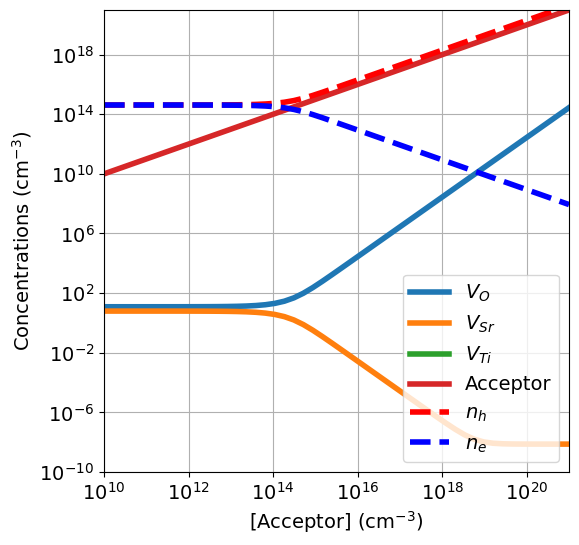

In [20]:
da_int.plot_doping_diagram(
                    variable_defect_specie={'name':'Acceptor','charge':-2},
                    concentration_range=(1e10,1e21),
                    chemical_potentials=chempots,
                    bulk_dos={'m_eff_e':0.5,'m_eff_h':0.4},
                    temperature=1000,
                    ylim=(1e-10,1e21),
                    figsize=(6,6),
                    fontsize=14);